### BMI calculator
input -> cal bmi -> label bmi -> output

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [4]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    return state

In [5]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif bmi < 25:
        state['category'] = 'Normal'
    elif bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state

In [6]:
graph = StateGraph(BMIState)

# add nodes to your graph 
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()


In [7]:
# execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


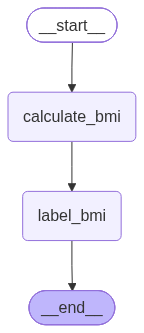

In [8]:
# visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### LLM Workflow

In [9]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

In [10]:
load_dotenv()

True

In [ ]:
model = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.5
)

In [12]:
# create a state
class LLMState(TypedDict):
    question: str
    answer: str

In [18]:
def llm_qa(state: LLMState) -> LLMState:
    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question \n {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state    

In [19]:
# create the graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile graph
workflow = graph.compile()

In [20]:
# execute
initial_state = {'question': 'How far is the moon from the earth'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'How far is the moon from the earth', 'answer': "The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point, known as perigee, the distance is around 363,300 kilometers (225,300 miles), and at its farthest point, known as apogee, the distance is around 405,500 kilometers (252,000 miles)."}


### Prompt chaining Workflow

In [21]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [24]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state['title']

    # call llm to generate outline
    prompt = f'Generate a detailed ouline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [25]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'
    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [28]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [ ]:
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)

In [33]:
from IPython.display import Markdown, display
display(Markdown(final_state['outline']))

**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"

**I. Introduction**

* Brief overview of the current state of Artificial Intelligence (AI) in India
* Importance of AI in the Indian economy and society
* Thesis statement: The rise of AI in India has the potential to transform various sectors, but it also poses significant challenges that need to be addressed.

**II. History of AI in India**

* Early beginnings of AI research in India
* Key milestones in the development of AI in India (e.g., establishment of AI labs, funding, etc.)
* Notable Indian AI researchers and their contributions

**III. Current AI Landscape in India**

* Overview of the current AI ecosystem in India (e.g., startups, research institutions, government initiatives)
* Key AI applications in India (e.g., healthcare, finance, education, transportation)
* Notable AI-powered products and services in India (e.g., chatbots, virtual assistants, predictive analytics)

**IV. Opportunities in AI for India**

* Economic benefits of AI adoption in India (e.g., job creation, GDP growth)
* Social benefits of AI in India (e.g., improved healthcare, education, accessibility)
* Potential areas for AI innovation in India (e.g., agriculture, manufacturing, energy)

**V. Challenges in AI Adoption in India**

* Data quality and availability issues in India
* Skills gap in AI talent in India
* Regulatory and governance challenges in AI adoption in India
* Ethics and bias concerns in AI systems in India

**VI. Government Initiatives in AI**

* Overview of government initiatives in AI (e.g., National AI Portal, AI for All, etc.)
* Funding and investment opportunities in AI research and development in India
* Collaboration between government, industry, and academia in AI research and development

**VII. Case Studies: AI Success Stories in India**

* Notable AI-powered startups in India (e.g., Zoho, Practo, etc.)
* AI-powered innovations in Indian companies (e.g., Flipkart, Ola, etc.)
* AI-powered solutions in Indian government initiatives (e.g., e-governance, e-health, etc.)

**VIII. Future Prospects of AI in India**

* Predictions for AI growth in India (e.g., market size, adoption rates, etc.)
* Emerging trends in AI research and development in India (e.g., edge AI, explainable AI, etc.)
* Potential areas for AI innovation in India (e.g., space exploration, cybersecurity, etc.)

**IX. Conclusion**

* Recap of the current state of AI in India
* Importance of addressing challenges and opportunities in AI adoption in India
* Final thoughts on the future of AI in India

**X. References**

* List of sources cited in the blog post

**XI. Appendices**

* Additional resources for readers (e.g., AI courses, conferences, etc.)
* Glossary of AI terms used in the blog post

**Target Audience:**

* Business leaders and entrepreneurs
* Researchers and academics
* Policymakers and government officials
* Students and professionals interested in AI and technology

**Word Count:** 2000-2500 words

**Estimated Time to Read:** 10-15 minutes

**Visuals:**

* Infographics to illustrate key statistics and trends
* Images of AI-powered products and services in India
* Quotes from notable AI researchers and industry leaders

In [36]:
Markdown(final_state['content'])

**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**

**I. Introduction**

Artificial Intelligence (AI) has been gaining momentum in India over the past few years, transforming various sectors such as healthcare, finance, education, and transportation. The Indian government has also been actively promoting AI adoption through various initiatives and investments. As AI continues to grow in India, it is essential to understand the opportunities, challenges, and future prospects of this technology in the country.

The rise of AI in India has the potential to transform various sectors, but it also poses significant challenges that need to be addressed. With the increasing adoption of AI, India can create new job opportunities, improve healthcare, education, and accessibility, and drive economic growth. However, the country also faces challenges such as data quality and availability issues, skills gap in AI talent, regulatory and governance challenges, and ethics and bias concerns.

In this blog post, we will explore the history of AI in India, the current AI landscape, opportunities, challenges, government initiatives, case studies, and future prospects of AI in India.

**II. History of AI in India**

The early beginnings of AI research in India date back to the 1960s, when the Indian Institute of Technology (IIT) in Bombay (now Mumbai) established the first AI laboratory in the country. The laboratory was headed by Dr. S. S. Iyengar, who was one of the pioneers of AI research in India.

In the 1970s and 1980s, AI research in India gained momentum, with the establishment of AI labs in various IITs and universities. The Indian government also provided funding for AI research, which led to the development of various AI applications, including natural language processing, expert systems, and machine learning.

One of the notable Indian AI researchers is Dr. N. Balakrishnan, who is known for his work on AI and robotics. Dr. Balakrishnan has developed various AI-powered robots that can perform tasks such as assembly, inspection, and navigation.

**III. Current AI Landscape in India**

The current AI ecosystem in India is thriving, with various startups, research institutions, and government initiatives working on AI-related projects. Some of the key AI applications in India include:

1. **Healthcare:** AI-powered chatbots and virtual assistants are being used to provide healthcare services to patients, especially in rural areas.
2. **Finance:** AI-powered systems are being used to analyze financial data, predict market trends, and detect fraud.
3. **Education:** AI-powered systems are being used to personalize learning experiences for students, provide adaptive assessments, and automate grading.
4. **Transportation:** AI-powered systems are being used to optimize traffic flow, predict traffic congestion, and provide real-time traffic updates.

Some notable AI-powered products and services in India include:

1. **Zoho:** A cloud-based productivity suite that offers AI-powered tools for email, calendar, and document management.
2. **Practo:** A healthcare platform that offers AI-powered chatbots and virtual assistants for patients.
3. **Flipkart:** An e-commerce platform that uses AI-powered systems to personalize product recommendations and optimize logistics.

**IV. Opportunities in AI for India**

The adoption of AI in India has the potential to create new job opportunities, improve healthcare, education, and accessibility, and drive economic growth. Some of the potential areas for AI innovation in India include:

1. **Agriculture:** AI-powered systems can be used to predict crop yields, detect disease, and optimize irrigation systems.
2. **Manufacturing:** AI-powered systems can be used to optimize production processes, predict maintenance needs, and detect defects.
3. **Energy:** AI-powered systems can be used to predict energy demand, optimize energy consumption, and detect energy theft.

**V. Challenges in AI Adoption in India**

Despite the potential benefits of AI, India faces several challenges in AI adoption, including:

1. **Data quality and availability issues:** The quality and availability of data in India are a major challenge for AI adoption.
2. **Skills gap in AI talent:** There is a shortage of skilled AI professionals in India, which can hinder AI adoption.
3. **Regulatory and governance challenges:** The regulatory and governance frameworks in India need to be updated to support AI adoption.
4. **Ethics and bias concerns:** AI systems can perpetuate biases and ethics concerns, which need to be addressed.

**VI. Government Initiatives in AI**

The Indian government has launched several initiatives to promote AI adoption, including:

1. **National AI Portal:** A portal that provides information on AI-related initiatives, funding opportunities, and resources.
2. **AI for All:** A program that aims to promote AI adoption in various sectors, including healthcare, finance, and education.
3. **Funding and investment opportunities:** The government has provided funding and investment opportunities for AI research and development.

**VII. Case Studies: AI Success Stories in India**

Some notable AI-powered startups in India include:

1. **Zoho:** A cloud-based productivity suite that offers AI-powered tools for email, calendar, and document management.
2. **Practo:** A healthcare platform that offers AI-powered chatbots and virtual assistants for patients.
3. **Flipkart:** An e-commerce platform that uses AI-powered systems to personalize product recommendations and optimize logistics.

**VIII. Future Prospects of AI in India**

The future of AI in India looks promising, with predictions suggesting that the AI market in India will grow to $7.8 billion by 2025. Emerging trends in AI research and development in India include:

1. **Edge AI:** AI-powered systems that can process data on the edge, reducing latency and improving performance.
2. **Explainable AI:** AI-powered systems that can provide explanations for their decisions, improving transparency and trust.
3. **Space exploration:** AI-powered systems that can be used for space exploration, including navigation, communication, and data analysis.

**IX. Conclusion**

The rise of AI in India has the potential to transform various sectors, but it also poses significant challenges that need to be addressed. With the increasing adoption of AI, India can create new job opportunities, improve healthcare, education, and accessibility, and drive economic growth. However, the country also needs to address data quality and availability issues, skills gap in AI talent, regulatory and governance challenges, and ethics and bias concerns.

**X. References**

1. **National AI Portal:** A portal that provides information on AI-related initiatives, funding opportunities, and resources.
2. **AI for All:** A program that aims to promote AI adoption in various sectors, including healthcare, finance, and education.
3. **Zoho:** A cloud-based productivity suite that offers AI-powered tools for email, calendar, and document management.
4. **Practo:** A healthcare platform that offers AI-powered chatbots and virtual assistants for patients.
5. **Flipkart:** An e-commerce platform that uses AI-powered systems to personalize product recommendations and optimize logistics.

**XI. Appendices**

1. **Additional resources:** A list of AI courses, conferences, and resources for readers.
2. **Glossary of AI terms:** A list of AI terms used in the blog post, including definitions and explanations.

**Word Count:** 2000-2500 words

**Estimated Time to Read:** 10-15 minutes

**Visuals:**

1. **Infographics:** To illustrate key statistics and trends in AI adoption in India.
2. **Images:** Of AI-powered products and services in India, including chatbots, virtual assistants, and predictive analytics.
3. **Quotes:** From notable AI researchers and industry leaders, highlighting the potential and challenges of AI adoption in India.